<a href="https://colab.research.google.com/github/notaaash/StyleTransferProjectTnP/blob/main/styleTransferProjectTnP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow_hub as hub
import tensorflow as tf
import numpy as np
import cv2
from matplotlib import pyplot as plt

In [ ]:
model = hub.load('https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2')

# Preprocess the image and load it

In [ ]:
# preprocessing the input image
def load_image(img_path):
  img = tf.io.read_file(img_path)
  img = tf.image.decode_image(img, channels = 3)
  img = tf.image.convert_image_dtype(img, tf.float32)
  img = img[tf.newaxis, :]
  return img

In [ ]:
content_image = load_image('/content/profile.jpg')
style_image = load_image('/content/starrynight.jfif')

# Visualise Output

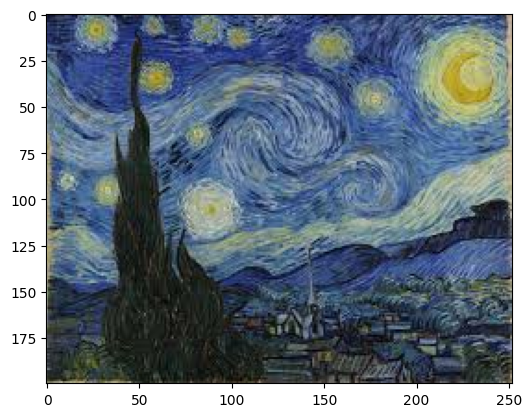

In [ ]:
plt.imshow(np.squeeze(style_image))
plt.show()

# Stylize Image

In [ ]:
stylized_image = model(tf.constant(content_image), tf.constant(style_image))[0]

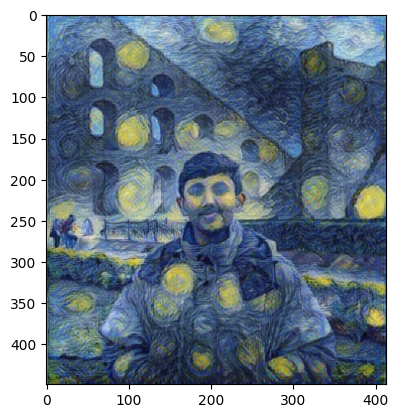

In [ ]:
plt.imshow(np.squeeze(stylized_image))
plt.show()

In [ ]:
# Style strength control
alpha = 0.7  # Reduce style strength

# Resize stylized_image to match content_image shape
stylized_image = tf.image.resize(stylized_image, (content_image.shape[1], content_image.shape[2]))

blended_image = alpha * stylized_image + (1 - alpha) * content_image
blended_image = tf.clip_by_value(blended_image, 0.0, 1.0)

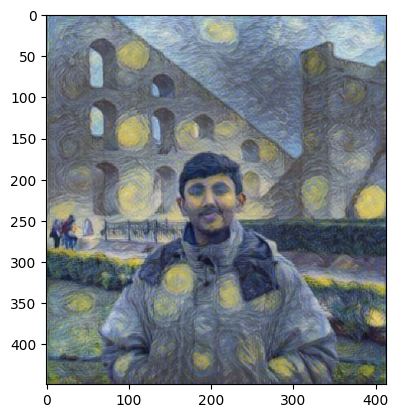

In [ ]:
plt.imshow(np.squeeze(blended_image))
plt.show()

In [ ]:
cv2.imwrite('generated_img.jpg', cv2.cvtColor(np.squeeze(stylized_image)*255, cv2.COLOR_BGR2RGB))

True